# 📧 Spam Email Detection using Classical Machine Learning

## Project Objective

Spam messages are one of the oldest real-world applications of Natural Language Processing (NLP).

In this project, we build a complete spam detection pipeline using classical machine learning techniques.

The workflow includes:

- Data Cleaning
- Exploratory Data Analysis
- Text Preprocessing
- Feature Engineering
- TF-IDF Vectorization
- Model Benchmarking
- Error Analysis

Finally, multiple machine learning algorithms are compared to determine the best spam classifier.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# 📂 Loading the Dataset

The SMS Spam Collection dataset contains labelled SMS messages belonging to two categories:

- Ham (Normal Message)
- Spam (Unwanted Promotional Message)

This dataset is widely used as a benchmark for classical NLP classification problems.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


# 🧹 Data Cleaning

The raw dataset contains unnecessary columns and duplicate records.

This section prepares the dataset for further analysis by:

- Removing irrelevant columns
- Renaming features
- Removing duplicate messages

In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
df.drop(
    columns=[
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4"
    ],
    inplace=True
)

In [8]:
df.rename(
    columns={
        "v1":"label",
        "v2":"message"
    },
    inplace=True
)

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df.drop_duplicates(inplace=True)

# 📊 Exploratory Data Analysis

Before building any machine learning model, it is important to understand the dataset distribution.

We first examine the balance between spam and ham messages.

In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

## Observation

The dataset is imbalanced, with ham messages significantly outnumbering spam messages.

This is expected in real-world SMS datasets and should be considered during model evaluation.

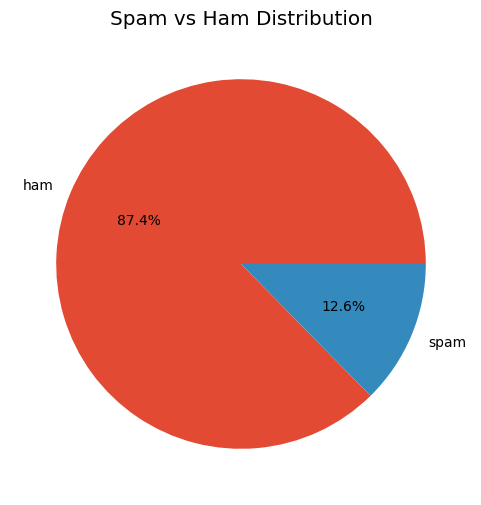

In [13]:
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Spam vs Ham Distribution")

plt.show()

In [14]:
df["label"] = df["label"].map({
    "ham":0,
    "spam":1
})

In [15]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# 🧠 Text Preprocessing

Raw text cannot be directly processed by machine learning algorithms.

The preprocessing pipeline performs:

- Lowercasing
- Tokenization
- Stopword Removal
- Punctuation Removal
- Stemming

The resulting cleaned text will later be converted into numerical features.

In [16]:
df.shape

(5169, 2)

In [17]:
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download("punkt")
nltk.download("stopwords")

ps = PorterStemmer()

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def transform_text(text):

    #Lowercase
    text = text.lower()

    #Tokenization
    text = nltk.word_tokenize(text)

    y = []

    #Keep only alphanumeric words
    for word in text:
        if word.isalnum():
            y.append(word)

    text = y[:]
    y.clear()

    #Remove Stopwords and Punctuation
    for word in text:
        if(
            word not in stopwords.words("english")
            and word not in string.punctuation
        ):
            y.append(word)

    text = y[:]
    y.clear()

    #Stemming
    for word in text:
        y.append(
            ps.stem(word)
        )

    return " ".join(y)

In [19]:
transform_text(
    "Congratulations! You have won a free Iphone worth $1000!!!"
)

'congratul free iphon worth 1000'

In [20]:
df["transformed_message"] = df["message"].apply(
    transform_text
)

## Observation

The preprocessing pipeline successfully removes unnecessary words while preserving meaningful information.

This significantly reduces noise within the dataset.

In [21]:
df.head()

,label,message,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


# 📈 Feature Engineering

Apart from textual features, additional numerical features are extracted:

- Character Count
- Word Count
- Sentence Count

These features help investigate behavioural differences between spam and legitimate messages.

In [22]:
df[["message","transformed_message"]].head(3)

,message,transformed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...


In [23]:
df["num_characters"] = df["message"].apply(len)

In [24]:
df["num_words"] = df["message"].apply(
    lambda x: len(nltk.word_tokenize(x))
)

In [25]:
df["num_sentences"] = df["message"].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [26]:
df.head()

,label,message,transformed_message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,111,24,2
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...,155,37,2
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,61,15,1


In [27]:
df.describe()

,label,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


## Observation

Spam messages generally contain:

- More characters
- More words
- More sentences

These engineered features provide additional insight into the dataset.

In [28]:
df.groupby("label")[
    ["num_characters","num_words","num_sentences"]
].mean()

,num_characters,num_words,num_sentences
label,,,
0,70.459256,17.123782,1.820195
1,137.891271,27.667688,2.970904


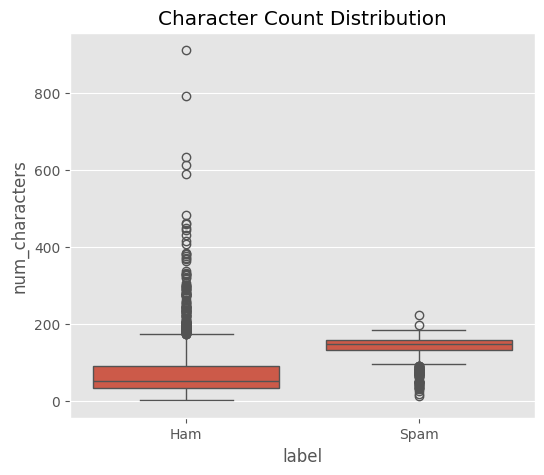

In [29]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="label",
    y="num_characters",
    data=df
)

plt.xticks([0,1], ["Ham","Spam"])

plt.title("Character Count Distribution")

plt.show()

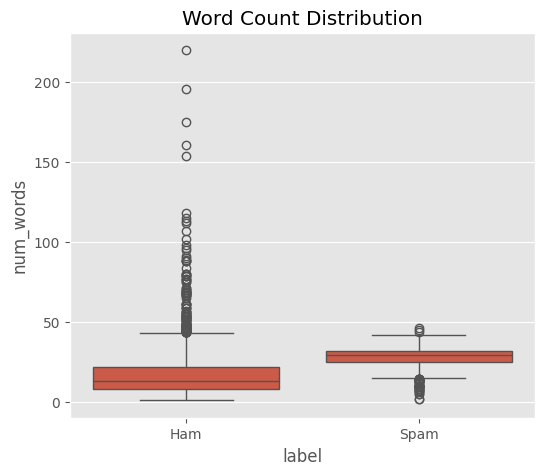

In [30]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="label",
    y="num_words",
    data=df
)

plt.xticks([0,1], ["Ham","Spam"])

plt.title("Word Count Distribution")

plt.show()

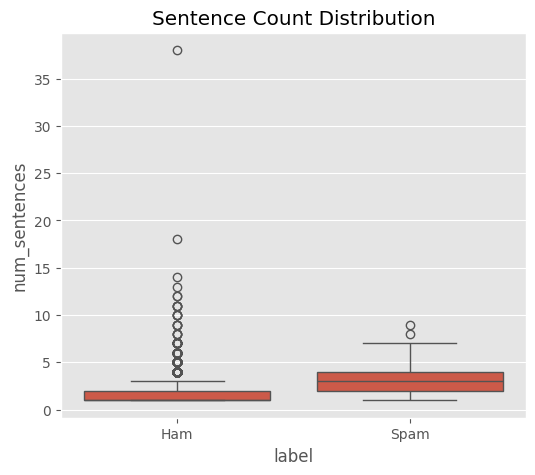

In [31]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="label",
    y="num_sentences",
    data=df
)

plt.xticks([0,1], ["Ham","Spam"])

plt.title("Sentence Count Distribution")

plt.show()

# ☁️ Word Cloud Visualization

Word Clouds provide an intuitive visualization of the most frequently occurring words within spam and ham messages.

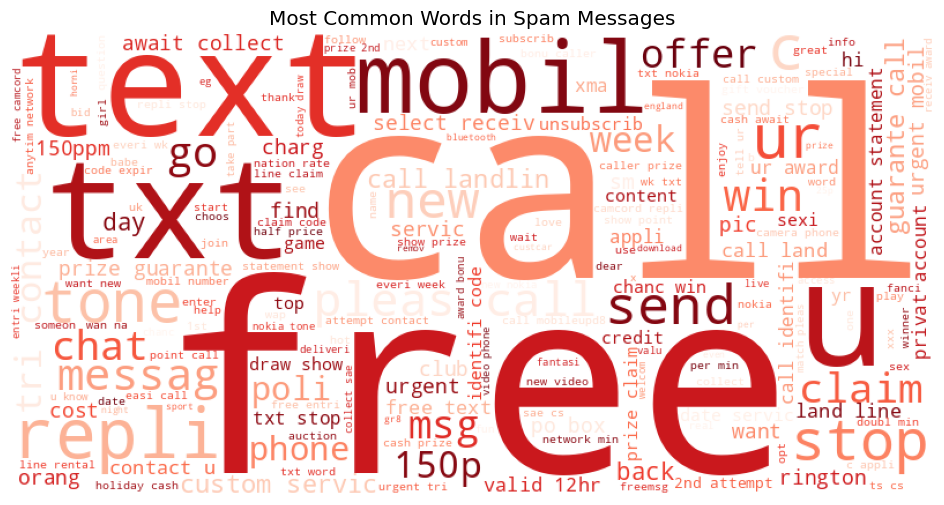

In [32]:
from wordcloud import WordCloud

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
)

spam_text = " ".join(
    df[df["label"] == 1]["transformed_message"]
)

spam_wc.generate(spam_text)

plt.figure(figsize=(12,6))

plt.imshow(spam_wc)

plt.axis("off")

plt.title("Most Common Words in Spam Messages")

plt.show()

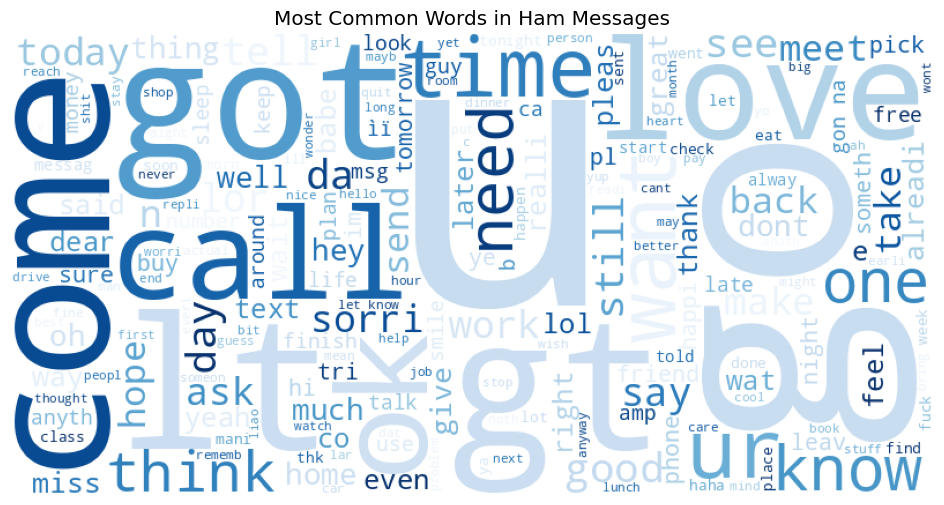

In [33]:
ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues"
)

ham_text = " ".join(
    df[df["label"]== 0]["transformed_message"]
)

ham_wc.generate(ham_text)

plt.figure(figsize=(12,6))

plt.imshow(ham_wc)

plt.axis("off")

plt.title("Most Common Words in Ham Messages")

plt.show()

In [34]:
from collections import Counter

spam_words = []

for msg in df[df["label"] == 1]["transformed_message"]:
    spam_words.extend(msg.split())

spam_common = Counter(spam_words).most_common(20)

spam_df = pd.DataFrame(
    spam_common,
    columns=["Word", "Frequency"]
)

spam_df

,Word,Frequency
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


## Observation

Spam messages frequently contain promotional keywords such as:

- free
- call
- txt
- stop
- prize

Whereas ham messages mostly consist of conversational language.

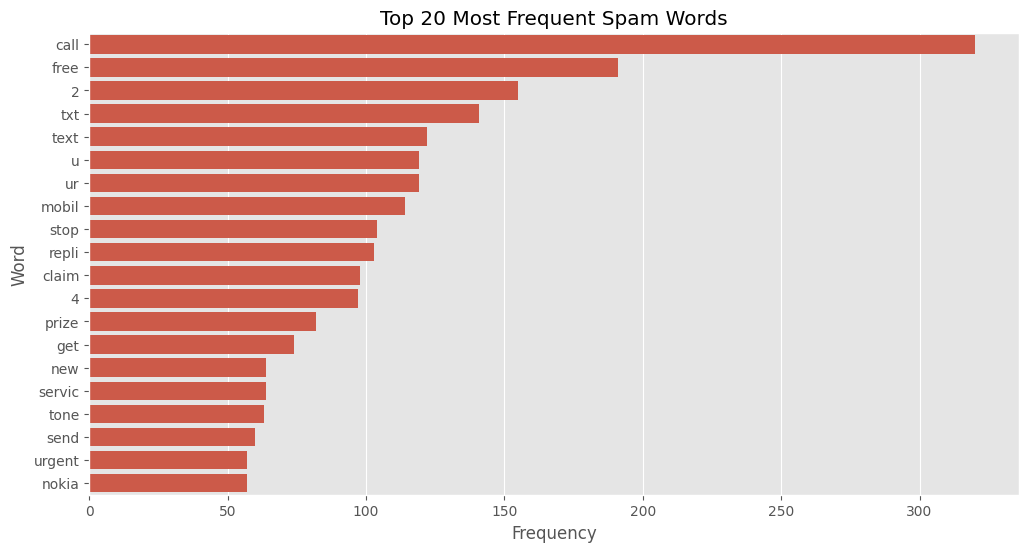

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=spam_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Spam Words")

plt.show()

In [36]:
ham_words=[]

for msg in df[df["label"] == 0]["transformed_message"]:
    ham_words.extend(msg.split())

ham_common = Counter(ham_words).most_common(20)

ham_df = pd.DataFrame(
    ham_common,
    columns=["Word","Frequency"]
)

ham_df

,Word,Frequency
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


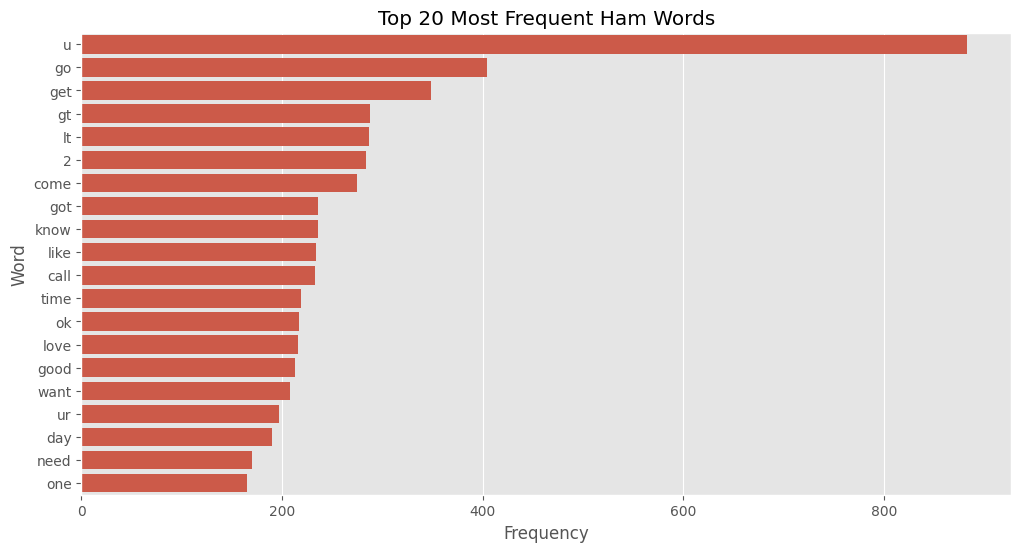

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=ham_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Ham Words")
plt.show()

# 🔤 TF-IDF Feature Extraction

Machine learning models require numerical input.

TF-IDF (Term Frequency–Inverse Document Frequency) converts cleaned text into numerical vectors while assigning higher importance to informative words.

In [38]:
X = df["transformed_message"]
y = df["label"]

In [39]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [41]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [42]:
X_test_tfidf = tfidf.transform(X_test)

In [43]:
X_train_tfidf.shape,X_test_tfidf.shape

((4135, 5000), (1034, 5000))

## Observation

Each SMS message is now represented as a sparse numerical vector.

This vector representation serves as the input for the classification models.

In [44]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36659 stored elements and shape (4135, 5000)>

# 🤖 Baseline Model — Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most commonly used algorithms for text classification.

It provides an excellent baseline for spam detection.

In [45]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train_tfidf,y_train)

MultinomialNB()

In [46]:
y_pred = mnb.predict(X_test_tfidf)

## Baseline Performance

The Naive Bayes classifier achieves high precision while maintaining strong overall accuracy.

However, its recall suggests that some spam messages remain undetected.

In [47]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.965183752417795


In [48]:
print("Precision:",precision_score(y_test,y_pred))

Precision: 0.9896907216494846


In [49]:
print("Recall:",recall_score(y_test,y_pred))

Recall: 0.732824427480916


In [50]:
print("F1 Score:",f1_score(y_test,y_pred))

F1 Score: 0.8421052631578947


In [51]:
print("Classification Report:",classification_report(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



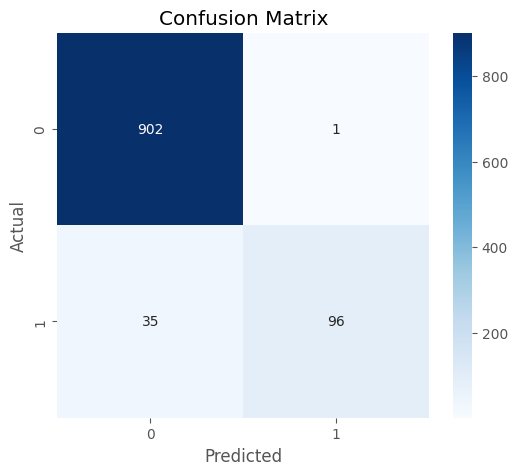

In [52]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [54]:
models = {
    "Naive Bayes":MultinomialNB(),
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Linear SVM":LinearSVC(),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
}

# 🏆 Model Benchmarking

To identify the best spam classifier, multiple machine learning algorithms are evaluated using identical TF-IDF features.

The following models are compared:

- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM
- Random Forest
- Gradient Boosting

In [55]:
results=[]

for name,model in  models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,preds),
        "Precision":precision_score(y_test,preds),
        "Recall":recall_score(y_test,preds),
        "F1":f1_score(y_test,preds)
    })

## Results

Among all evaluated models, **Linear SVM** achieved the highest F1 score while maintaining excellent accuracy and precision.

This demonstrates that Linear SVM is particularly well suited for sparse TF-IDF representations in text classification tasks.

In [56]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Linear SVM,0.980658,0.982609,0.862595,0.918699
3,Random Forest,0.974855,0.981651,0.816794,0.891667
0,Naive Bayes,0.965184,0.989691,0.732824,0.842105
1,Logistic Regression,0.963250,1.000000,0.709924,0.830357
4,Gradient Boosting,0.959381,0.968421,0.702290,0.814159


# 🔍 Error Analysis

Rather than only examining performance metrics, it is equally important to inspect incorrectly classified messages.

Studying false positives and false negatives helps identify limitations of the current model and opportunities for improvement.

In [57]:
errors = pd.DataFrame({
    "Message": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

errors = errors[errors["Actual"] != errors["Predicted"]]

# 📈 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates a classifier across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between spam and ham messages.

Higher AUC values indicate better discrimination performance.

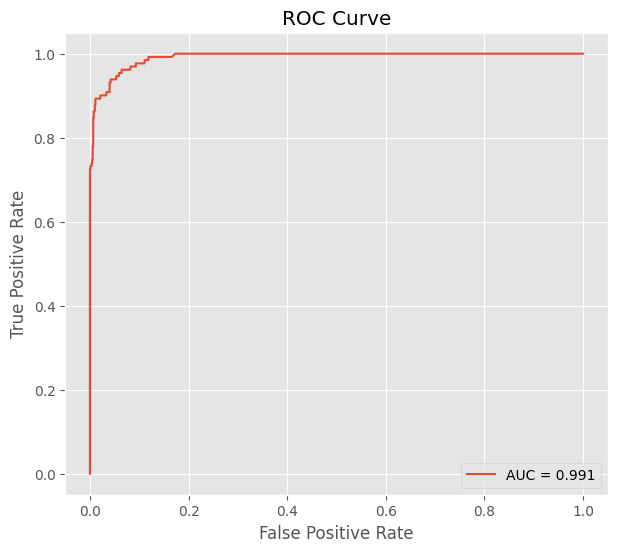

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_tfidf, y_train)
y_prob = log_reg.predict_proba(X_test_tfidf)[:,1]
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)
auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Observation

The ROC curve demonstrates the classifier's ability to separate spam from legitimate messages across different thresholds.

An AUC value close to 1 indicates excellent discrimination performance.

# 🚀 Spam Detection System

After training the best-performing classifier, a reusable prediction function is created.

The function accepts raw SMS messages, applies the complete preprocessing pipeline, performs TF-IDF transformation, and predicts whether the message is spam or ham.

In [59]:
best_model = LinearSVC()

best_model.fit(X_train_tfidf,y_train)

LinearSVC()

In [60]:
def predict_spam(message):
    cleaned = transform_text(message)
    vector = tfidf.transform([cleaned])
    prediction = best_model.predict(vector)
    if prediction[0] == 1:
        return "🚨 Spam"
    return "✅ Ham"

In [61]:
predict_spam(
    "Congratulations! You've won a FREE iPhone. Click here now!"
)

'✅ Ham'

In [62]:
predict_spam(
    "Hey bro, are we meeting tomorrow?"
)

'✅ Ham'

In [63]:
predict_spam(
    "URGENT! Call this number immediately to claim your prize."
)

'🚨 Spam'

# 💾 Model Serialization

To enable future deployment, both the trained classifier and the TF-IDF vectorizer are saved to disk.

These files can later be loaded into applications such as Streamlit, Flask, or FastAPI without retraining the model.

In [64]:
import joblib 
joblib.dump(
    best_model,
    "linear_svm_spam_classifier.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [65]:
feature_names = tfidf.get_feature_names_out()

coef = best_model.coef_[0]

top_spam = np.argsort(coef)[-20:]

spam_df = pd.DataFrame({
    "Word":feature_names[top_spam],
    "Weight":coef[top_spam]
})

spam_df.sort_values(
    by="Weight",
    ascending=False
)

,Word,Weight
19,txt,2.298098
18,claim,2.004777
17,mobil,1.951743
16,http,1.904026
15,repli,1.811753
14,servic,1.750167
13,prize,1.706395
12,rington,1.429665
11,tone,1.381021
10,arsen,1.332465


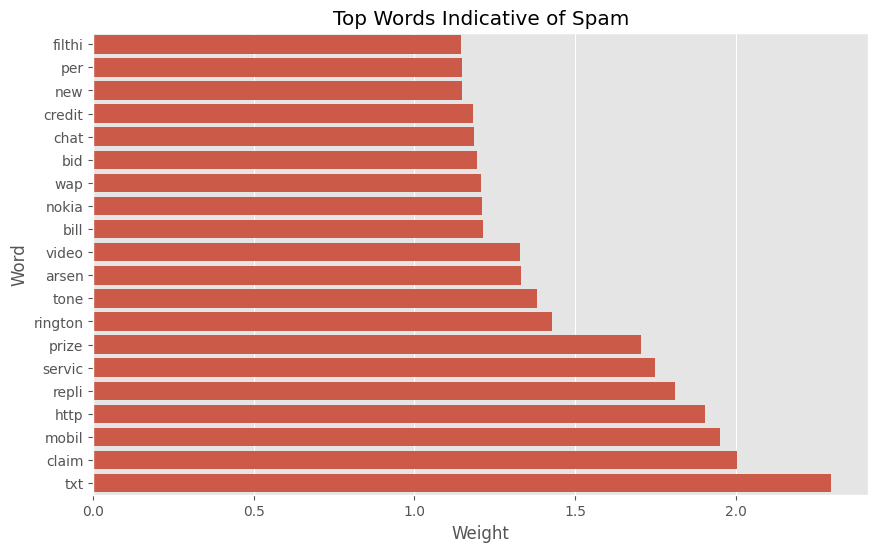

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=spam_df,
    x="Weight",
    y="Word"
)

plt.title("Top Words Indicative of Spam")

plt.show()

# 🎯 Conclusion

## Summary

This project explored classical Natural Language Processing techniques for spam detection.

### Major Findings

- TF-IDF effectively transformed textual data into numerical features.
- Classical machine learning models performed remarkably well.
- Linear SVM achieved the best balance between precision and recall.
- Word Clouds and feature engineering provided valuable insight into spam characteristics.

## Future Work

Potential improvements include:

- Hyperparameter tuning
- Bi-gram and tri-gram TF-IDF features
- Lemmatization
- Deep Learning (LSTM)
- Transformer-based models (BERT)
- Deployment using Streamlit